In [1]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import numpy as np
import duckdb
import matplotlib.pyplot as plt

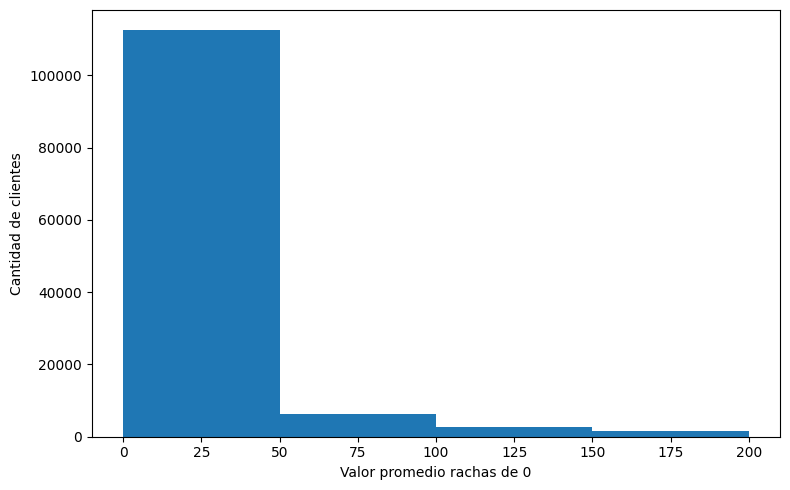

In [13]:
# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect('C:\\Users\\andres\\Documents\\analisis-residenciales-segmentos')

# Run the query
query = """
select customer_id, avg(count) as total
from segmentos
group by customer_id
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total"]

fixed_bins = np.array([0, 50, 100, 150, 200])

# Automatic bins for values >= 5000
#auto_bins = np.histogram_bin_edges(values[values >= 200], bins="auto")

# Combine (skip duplicate 5000)
#bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.hist(values, bins=fixed_bins)
plt.ylabel("Cantidad de clientes")
plt.xlabel("Valor promedio rachas de 0")
plt.title("")
plt.tight_layout()
plt.show()

con.close()
del df

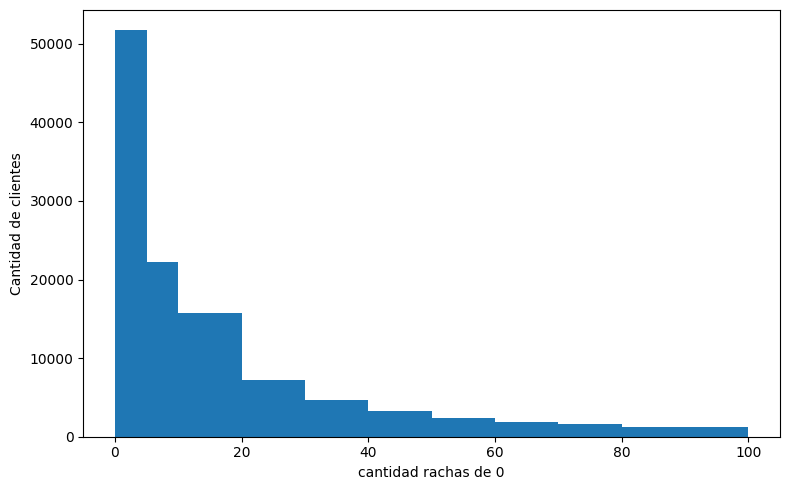

In [16]:
# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect('C:\\Users\\andres\\Documents\\analisis-residenciales-segmentos')

# Run the query
query = """
select customer_id, count(*) as total
from segmentos
group by customer_id
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total"]

fixed_bins = np.array([0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# Automatic bins for values >= 5000
#auto_bins = np.histogram_bin_edges(values[values >= 200], bins="auto")

# Combine (skip duplicate 5000)
#bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.hist(values, bins=fixed_bins)
plt.ylabel("Cantidad de clientes")
plt.xlabel("cantidad rachas de 0")
plt.title("")
plt.tight_layout()
plt.show()

con.close()
del df

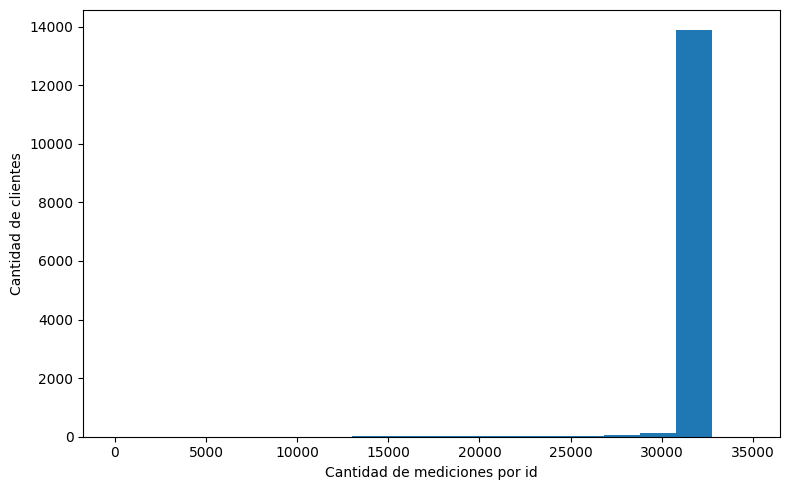

In [4]:
# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect()

# Run the query
query = """
select id, count(*) as total_datapoints
from read_parquet('C:\\Users\\andres\\Documents\\ute\\raw\\no_residenciales_anii\\**\\*.parquet')
where year > 2021
group by id
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total_datapoints"]

fixed_bins = np.array([0, 1000, 5000])

# Automatic bins for values >= 5000
auto_bins = np.histogram_bin_edges(values[values >= 5000], bins="auto")

# Combine (skip duplicate 5000)
bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.hist(values, bins=bins)
plt.xlabel("Cantidad de mediciones por id")
plt.ylabel("Cantidad de clientes")
plt.title("")
plt.tight_layout()
plt.show()

con.close()
del df

In [3]:
auto_bins

array([ 5112.,  7088.,  9064., 11040., 13016., 14992., 16968., 18944.,
       20920., 22896., 24872., 26848., 28824., 30800., 32776., 34752.])

In [ ]:
import pyarrow as pa
from pathlib import Path

# Configure paths
base_folder = Path(r"C:\Users\andres\Documents\ute\raw\anii_residenciales")
out_file = Path(r"C:\Users\andres\Documents\ute\processed\combined_data.parquet")

# Create output directory if it doesn't exist
out_file.parent.mkdir(parents=True, exist_ok=True)

# Find all parquet files recursively
parquet_files = list(base_folder.glob("**/*.parquet"))
print(f"Found {len(parquet_files)} parquet files")

# Process files one at a time and write incrementally
parquet_writer = None
total_rows = 0

for i, file in enumerate(parquet_files, 1):
    print(f"Processing {i}/{len(parquet_files)}: {file.name}")
    
    # Read one file at a time
    table = pq.read_table(file)
    total_rows += len(table)
    
    # Initialize writer with first file's schema
    if parquet_writer is None:
        parquet_writer = pq.ParquetWriter(out_file, table.schema, compression='snappy')
    
    # Write this batch to the output file
    parquet_writer.write_table(table)
    
    # Clear memory
    del table

# Close the writer
if parquet_writer:
    parquet_writer.close()
    print(f"\nDone! Combined {total_rows:,} rows from {len(parquet_files)} files")
    print(f"Output file: {out_file}")
    print(f"Output file size: {out_file.stat().st_size / 1024**2:.2f} MB")
else:
    print("No parquet files found to process")

Found 74 parquet files
Processing 1/74: part-00056-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 2/74: part-00057-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 3/74: part-00069-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 4/74: part-00070-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 5/74: part-00044-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 6/74: part-00045-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 7/74: part-00065-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 8/74: part-00066-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 9/74: part-00052-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 10/74: part-00053-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 11/74: part-00098-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet
Processing 12/74: part-00099-0cf868e2-20

In [ ]:
import polars as pl

result = (
    pl.scan_parquet(out_file)
    .group_by('id')
    .agg([
        pl.col('dia').min().alias('min_dia'),
        pl.col('dia').max().alias('max_dia')
    ])
    .collect()  # Execute the query
)




: 

In [5]:
print(pq.read_schema(Path(r"C:\Users\andres\Documents\ute\raw\anii_residenciales\year=2022\month=12\part-00044-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet")))

id: decimal128(19, 0)
dia: date32[day]
hora: int32
valor: double
tarifa: string
departamento: string
localidad: string
oficina: string
origen: string
-- schema metadata --
org.apache.spark.version: '3.3.2'
org.apache.spark.sql.parquet.row.metadata: '{"type":"struct","fields":[{"' + 581


In [3]:
import polars as pl

# Scan the parquet file lazily (doesn't load into memory immediately)
result = (
    pl.scan_parquet(Path(r"C:\Users\andres\Documents\ute\raw\anii_residenciales\year=2024\month=3\part-00050-0cf868e2-2028-4bec-ad81-c195cae397e0.c000.snappy.parquet"))
    .unique("id")
    .collect()  # Execute the query
)

print(len(result))

90849


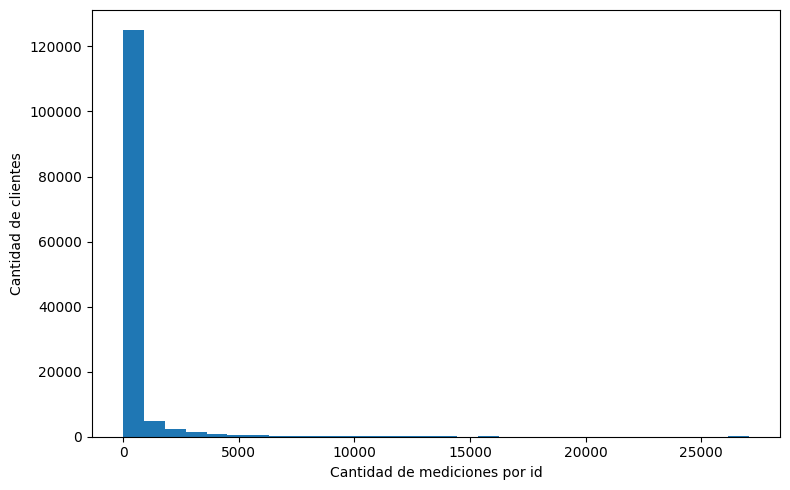

In [7]:

df = pd.read_parquet("C:\\Users\\andres\\Documents\\zeros.parquet")

# Extract the values to plot
values = df["max_zero_streak"]

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.hist(values, bins=30)
plt.xlabel("Cantidad de mediciones por id")
plt.ylabel("Cantidad de clientes")
plt.title("")
plt.tight_layout()
plt.show()

In [31]:
# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect('C:\\Users\\andres\\Documents\\analisis-residenciales-segmentos')

# Run the query
query = """
select id, daily_average as total
from analisis
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total"]

fixed_bins = np.array([0, 2.4, 3.76, 4.88, 8, 10])

# Automatic bins for values >= 5000
#auto_bins = np.histogram_bin_edges(values[values >= 200], bins="auto")

# Combine (skip duplicate 5000)
#bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
plt.figure(figsize=(8, 5))
plt.hist(values, bins=fixed_bins)
plt.ylabel("cantidad de clientes")
plt.xlabel("promedio diario")
plt.title("")
plt.tight_layout()
plt.show()

con.close()
#del df

IOException: IO Error: Cannot open file "c:\users\andres\documents\analisis-residenciales-segmentos": The process cannot access the file because it is being used by another process.

File is already open in 
C:\Users\andres\Documents\duckdb.exe (PID 157764)

In [30]:
df['total'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99])

0.10     2.393735
0.20     3.765693
0.30     4.888418
0.40     6.018876
0.50     7.247006
0.60     8.657361
0.70    10.366966
0.80    12.756754
0.90    17.012373
0.95    21.957567
0.96    23.853817
0.97    26.371502
0.98    30.470924
0.99    39.023808
Name: total, dtype: float32

In [2]:
def plot_segmento(id, dia):
    con = duckdb.connect("C:\\Users\\andres\\Documents\\analisis")

    query = """
    select dia, hora, valor
    from read_parquet('C:\\Users\\andres\\Documents\\ute\\cleanup\\res\\')
    where id = ?
    order by dia, hora
    """
    df1 = con.execute(query, [id]).fetchdf()
    df1['dia'] = df1['dia'] + pd.to_timedelta(df1['hora']-1, unit='h')
    df1.drop(columns=['hora'], inplace=True)
    df1.set_index('dia', inplace=True)

    query = """
    select start_date, end_date
    from segmentos
    where customer_id = ? AND start_date = ?
    order by start_date
    limit 1
    """
    dfs = con.execute(query, [id, dia]).fetchdf()
    print(len(dfs))

    _, axs = plt.subplots(len(dfs) + 1, 1, figsize=(16, 5 + len(dfs) * 3))

    df1['valor'].plot(ax=axs[0])

    for i, row in dfs.iterrows():
        query = """
        select dia, hora, valor
        from read_parquet('C:\\Users\\andres\\Documents\\ute\\cleanup\\res\\')
        where id = ? and dia >= ? and dia <= ?
        order by dia, hora
        """
        start = (row['start_date'] - pd.to_timedelta(5, unit='D')).strftime("%Y-%m-%d")
        end = (row['end_date'] + pd.to_timedelta(5, unit='D')).strftime("%Y-%m-%d")
        
        df = con.execute(query, [id, start, end]).fetchdf()
        df['dia'] = df['dia'] + pd.to_timedelta(df['hora']-1, unit='h')
        df.drop(columns=['hora'], inplace=True)
        df.set_index('dia', inplace=True)

        df['valor'].plot(ax=axs[i + 1])
        del df


    con.close()
    del df1
    del dfs

1


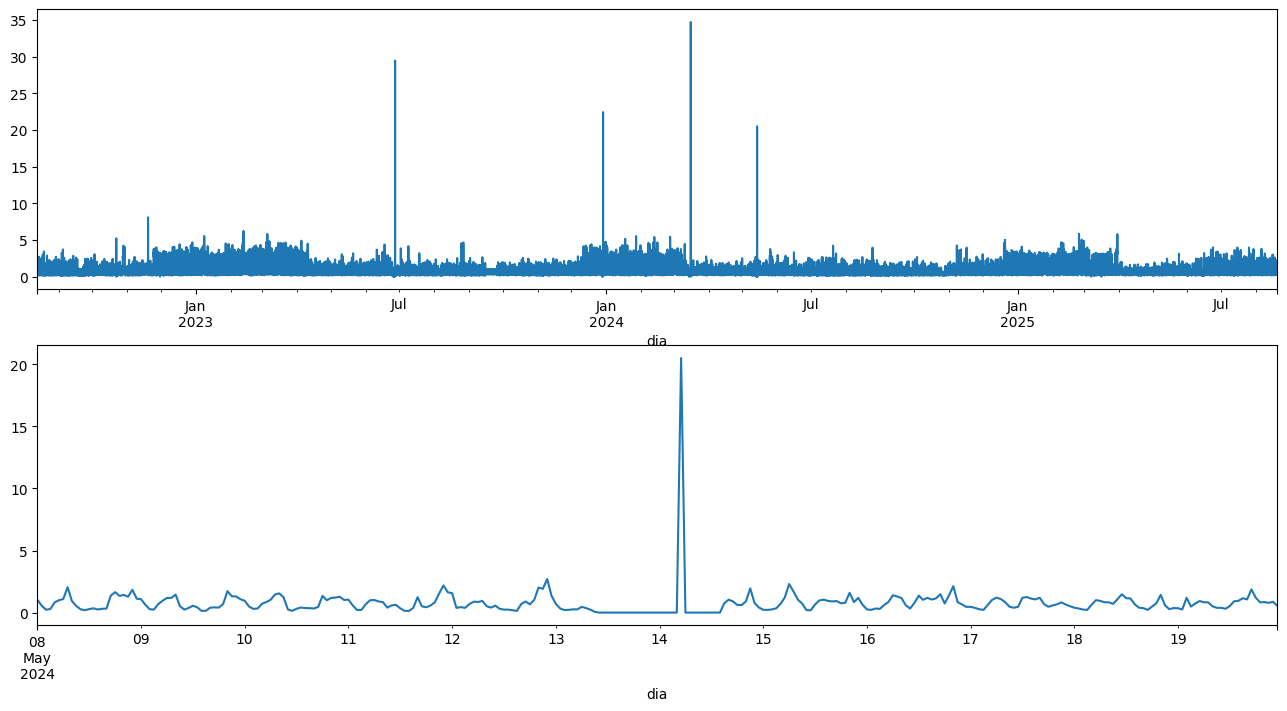

In [ ]:
# id=1932205, dia='2025-06-25', hora=4
#plot_segmento(1932205, '2025-06-25')

# id=2296611, dia='2024-11-02', hora=21
#plot_segmento(2296611, '2024-11-02')

# id=7416651, dia='2025-06-04', hora=16
#plot_segmento(7416651, '2025-06-04')

# id=8204094, dia='2024-09-30', hora=17
#plot_segmento(8204094, '2024-09-30')

# id=3994651, dia='2024-05-13', hora=13
#plot_segmento(3994651, '2024-05-13')

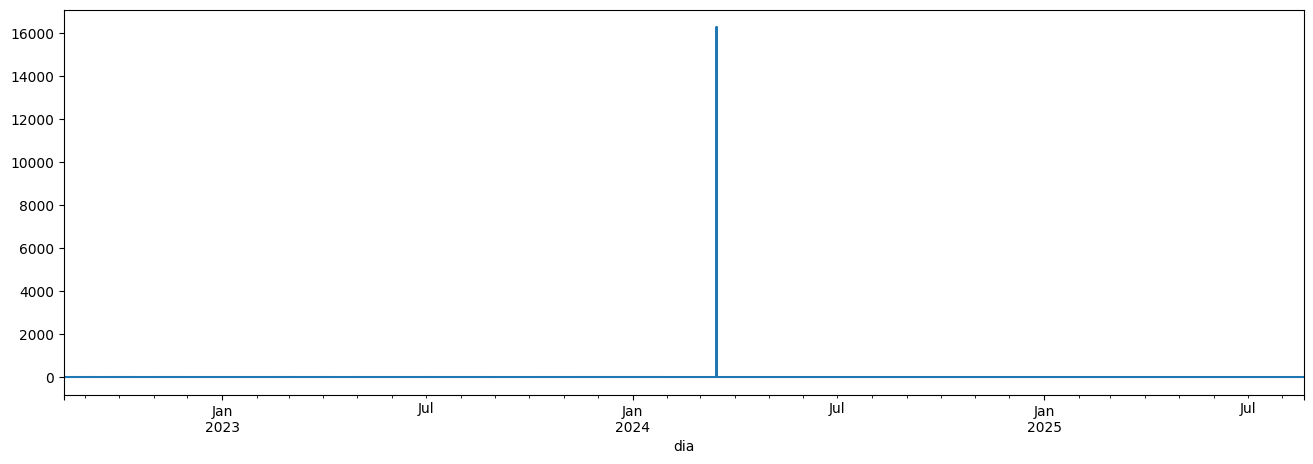

In [18]:
con = duckdb.connect()

# Run the query
#15825830

# ids consumo mayor a 200
# 12654463 
# 13649333 
# 15766698 
# 28375084 
# 8253822 
# 13580497 
query = """
select dia, hora, valor
from read_parquet('C:\\Users\\andres\\Documents\\ute\\cleanup\\res\\')
where id = 17831826
order by dia, hora
"""
# and dia >= '2025-03-08' and dia < '2025-03-25'
df = con.execute(query).fetchdf()
df['dia'] = df['dia'] + pd.to_timedelta(df['hora']-1, unit='h')
df.drop(columns=['hora'], inplace=True)
df.set_index('dia', inplace=True)

df['valor'].plot(figsize=(16,5))

con.close()
del df

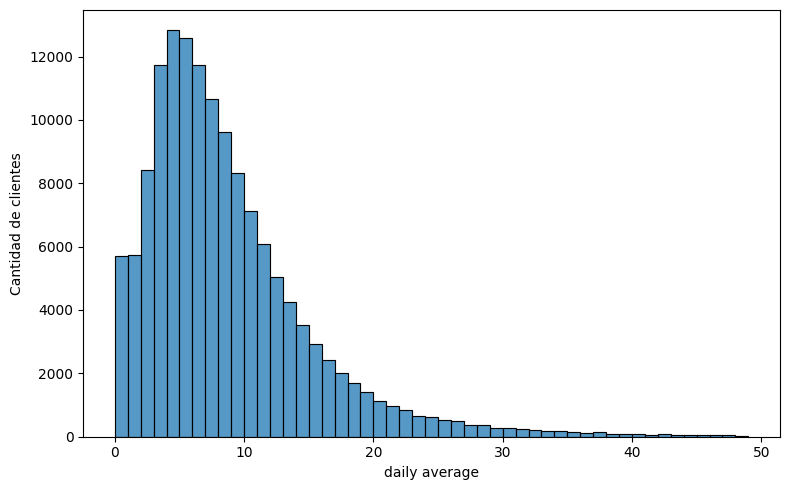

In [87]:
import seaborn as sns

# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect('C:\\Users\\andres\\Documents\\analisis-residenciales-segmentos')

# Run the query
query = """
select id, daily_average as total
from analisis
where daily_average < 50
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total"]

fixed_bins = np.array(range(50))

# Automatic bins for values >= 5000
#auto_bins = np.histogram_bin_edges(values[values >= 200], bins="auto")

# Combine (skip duplicate 5000)
#bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
plt.figure(figsize=(8, 5))
sns.histplot(values, bins=fixed_bins, stat='count') 
#plt.hist(values, bins=fixed_bins)
plt.ylabel("Cantidad de clientes")
plt.xlabel("daily average")
plt.title("")
plt.tight_layout()
plt.show()

con.close()
del df

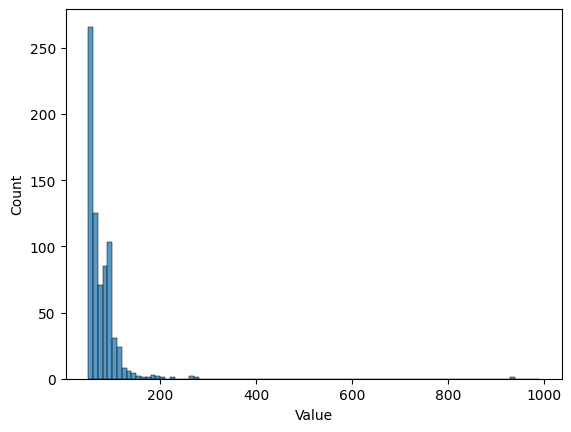

In [93]:
import seaborn as sns
# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect('C:\\Users\\andres\\Documents\\analisis-residenciales-segmentos')

# Run the query
query = """
select id, daily_average as total
from analisis
where daily_average >= 50
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total"]

fixed_bins = np.array(range(50, 1000, 10))

# Automatic bins for values >= 5000
#auto_bins = np.histogram_bin_edges(values[values >= 200], bins="auto")

# Combine (skip duplicate 5000)
#bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
sns.histplot(values, bins=fixed_bins, stat='count') 
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

con.close()
del df

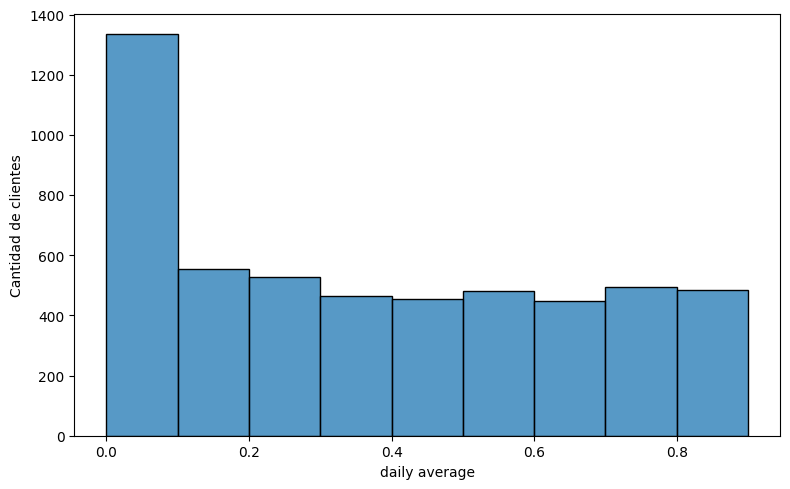

In [89]:
import seaborn as sns

# Connect to DuckDB (in-memory; change if you want a persistent DB)
con = duckdb.connect('C:\\Users\\andres\\Documents\\analisis-residenciales-segmentos')

# Run the query
query = """
select id, daily_average as total
from analisis
where daily_average < 1
"""
df = con.execute(query).fetchdf()

# Extract the values to plot
values = df["total"]

fixed_bins = np.arange(0.0, 1.0, 0.1)

# Automatic bins for values >= 5000
#auto_bins = np.histogram_bin_edges(values[values >= 200], bins="auto")

# Combine (skip duplicate 5000)
#bins = np.concatenate([fixed_bins, auto_bins[1:]])

# ---- Plot ----
plt.figure(figsize=(8, 5))
sns.histplot(values, bins=fixed_bins, stat='count') 
#plt.hist(values, bins=fixed_bins)
plt.ylabel("Cantidad de clientes")
plt.xlabel("daily average")
plt.title("")
plt.tight_layout()
plt.show()

con.close()
del df